In [37]:
import random
from typing import Any, cast

import numpy as np
import pandas as pd
import seaborn as sns
from pandas import DataFrame, Series
from sklearn.metrics import accuracy_score, confusion_matrix

In [85]:
iris = cast(DataFrame, pd.read_csv("../../data/iris.csv"))

In [86]:
label = "variety"
features = ["sepal.length", "sepal.width", "petal.length", "petal.width"]

In [87]:
iris.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [49]:
def shuffle_dataset(data: DataFrame) -> None:
    for i in range(len(data)):
        random_id = random.randint(0, len(data) - 1)
        data.iloc[i], data.iloc[random_id] = data.iloc[random_id], data.iloc[i]


def split_dataset(data: DataFrame, percentage: float) -> tuple[DataFrame, DataFrame]:
    assert 0 <= percentage <= 1

    take = int(len(data) * percentage)
    return data[:take], data[take:]

In [88]:
shuffle_dataset(iris)
train_data, validation_data = split_dataset(iris, 0.7)

In [89]:
X_train, y_train = train_data[features], train_data[label]
X_validation, y_validation = validation_data[features], validation_data[label]

In [52]:
def series_entropy(data: Series) -> float:
    probabilities = data.value_counts(normalize=True)
    return -(probabilities * np.log2(probabilities)).sum()

In [90]:
def _c45_calculate_threshold(values: Series, labels: Series) -> tuple[float, float]:
    sorted_df = DataFrame({"value": values, "label": labels}).sort_values(by="value")

    values = sorted_df["value"].values
    labels = sorted_df["label"]

    n = len(sorted_df)

    labels_entropy = series_entropy(labels)

    best_split = (-1, 0)

    for i in range(1, n):
        if values[i - 1] == values[i]:
            continue

        left_entropy = series_entropy(labels[:i])
        right_entropy = series_entropy(labels[i:])

        left_probability = i / n
        right_probability = 1 - left_probability

        weighted_sides_entropy = left_probability * left_entropy + right_probability * right_entropy

        entropy_gain = labels_entropy - weighted_sides_entropy
        split_entropy = -(left_probability * np.log2(left_probability) + right_probability * np.log2(right_probability))

        entropy_gain_ratio = entropy_gain / split_entropy

        if entropy_gain_ratio > best_split[0]:
            threshold = (values[i - 1] + values[i]) / 2
            best_split = (entropy_gain_ratio, threshold)

    return best_split


def c45_build_tree(data: DataFrame, labels: Series, max_depth: int | None = None) -> dict:
    if len(data) < 1:
        return {"leaf": True}

    if len(data) < 2:
        return {"leaf": True, "value": labels.iloc[0]}

    if max_depth is not None:
        if max_depth < 1:
            return {"leaf": True, "value": labels.mode().iloc[0]}
        else:
            max_depth -= 1

    best_feature = ("", -1, 0)

    for column in data.columns:
        gain, threshold = _c45_calculate_threshold(data[column], labels)

        if gain <= best_feature[1]:
            continue

        best_feature = column, gain, threshold

    column, gain, threshold = best_feature

    if gain <= 0:
        return {"leaf": True, "value": labels.mode().iloc[0]}

    left = data[data[column] < threshold]
    right = data[data[column] > threshold]

    return {"leaf": False, "feature": column, "threshold": threshold,
            "left": c45_build_tree(left, labels[left.index], max_depth),
            "right": c45_build_tree(right, labels[right.index], max_depth)}


def _c45_classify_single(tree: dict, row: Series) -> Any:
    node = tree

    while node and not node["leaf"]:
        value = row[node["feature"]]

        if value < node["threshold"]:
            node = node["left"]
        else:
            node = node["right"]

    if node and node["leaf"]:
        return node["value"]

    return None


def c45_classify(tree: dict, data: DataFrame) -> Series:
    return data.apply(lambda row: _c45_classify_single(tree, row), axis=1)

In [117]:
tree = c45_build_tree(X_train, y_train, max_depth=2)
y_predicted = c45_classify(tree, X_validation)

In [118]:
accuracy = accuracy_score(y_validation, y_predicted)
confusion = confusion_matrix(y_validation, y_predicted)

In [119]:
print(f"Dokładność wynosi {accuracy * 100:.2f}%")

Dokładność wynosi 95.56%


<Axes: >

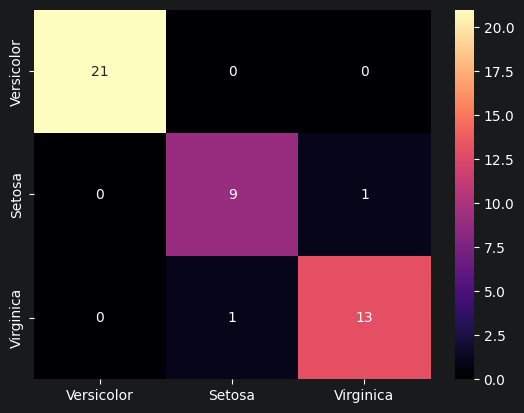

In [120]:
label_classes = iris[label].unique()
sns.heatmap(confusion, annot=True, cmap='magma', xticklabels=label_classes, yticklabels=label_classes)

In [121]:
tree

{'leaf': False,
 'feature': 'petal.length',
 'threshold': np.float64(2.45),
 'left': {'leaf': True, 'value': 'Setosa'},
 'right': {'leaf': False,
  'feature': 'petal.width',
  'threshold': np.float64(1.65),
  'left': {'leaf': True, 'value': 'Versicolor'},
  'right': {'leaf': True, 'value': 'Virginica'}}}